## Imports & Setup

In [26]:

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use("seaborn-v0_8")


## Load Dataset

In [27]:

def load_data(path="train_FD001.txt"):
    cols = (
        ['engine_id','cycle'] +
        ['setting1','setting2','setting3'] +
        [f'sensor{i}' for i in range(1,22)]
    )
    df = pd.read_csv(path, sep=" ", header=None)
    df.dropna(axis=1, inplace=True)
    df.columns = cols
    return df

train_df = load_data()


## RUL Engineering

In [28]:

RUL_CAP = 125

def compute_rul(df, cap=125):
    max_cycles = df.groupby("engine_id")["cycle"].max()
    df["RUL_raw"] = df.apply(lambda r: max_cycles[r.engine_id] - r.cycle, axis=1)
    df["RUL"] = df["RUL_raw"].clip(upper=cap)
    df["RUL_norm"] = df["RUL"] / cap
    return df

train_df = compute_rul(train_df)


## Feature Selection & Scaling

In [29]:

def select_and_scale(df, threshold=0.01):
    sensors = [f"sensor{i}" for i in range(1,22)]
    features = df[sensors].std()[df[sensors].std() > threshold].index.tolist()
    scaler = MinMaxScaler()
    df[features] = scaler.fit_transform(df[features])
    return df, features, scaler

train_df, features, scaler = select_and_scale(train_df)


## Sequence Generation

In [30]:

def create_sequences(df, features, seq_len=30):
    X, y = [], []
    for eid in df.engine_id.unique():
        edf = df[df.engine_id == eid]
        data = edf[features].values
        rul = edf.RUL_norm.values
        for i in range(len(data) - seq_len):
            X.append(data[i:i+seq_len])
            y.append(rul[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 30


## CNN Model Training

In [31]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense

X, y = create_sequences(train_df, features, SEQ_LEN)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(SEQ_LEN, X.shape[2])),
    Conv1D(64, 3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=8, batch_size=64, verbose=1)


Epoch 1/8


c:\Users\aksha\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0612 - val_loss: 0.0311
Epoch 2/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0309 - val_loss: 0.0299
Epoch 3/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0296 - val_loss: 0.0290
Epoch 4/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0290 - val_loss: 0.0298
Epoch 5/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0286 - val_loss: 0.0280
Epoch 6/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0285 - val_loss: 0.0295
Epoch 7/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0281 - val_loss: 0.0275
Epoch 8/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0275 - val_loss: 0.0273


## CNN Evaluation

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


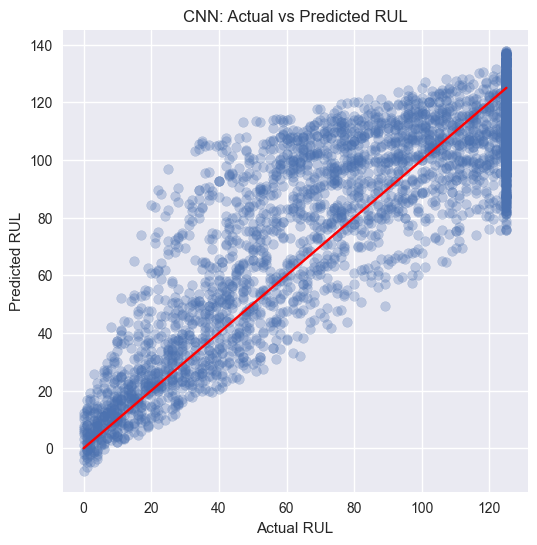

{'RMSE': np.float64(0.1653045335853146),
 'MAE': 0.12707709076156484,
 'R2': 0.756696677621076}

In [32]:

y_pred = model.predict(X_val).flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_val*RUL_CAP, y_pred*RUL_CAP, alpha=0.3)
plt.plot([0, RUL_CAP],[0, RUL_CAP],'r')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("CNN: Actual vs Predicted RUL")
plt.show()

metrics_cnn = {
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
    "MAE": mean_absolute_error(y_val, y_pred),
    "R2": r2_score(y_val, y_pred)
}
metrics_cnn


CNN Training Curve

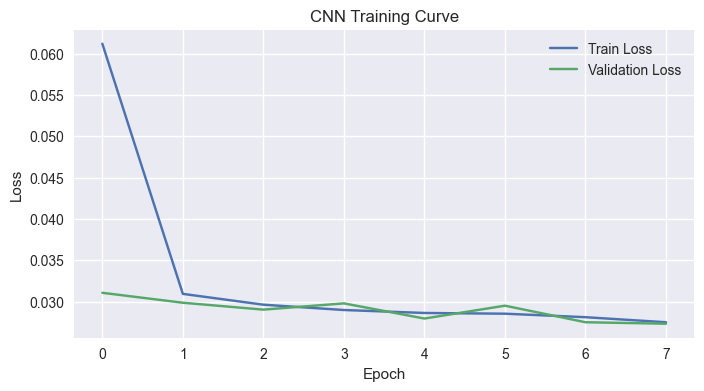

In [33]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Curve")
plt.legend()
plt.grid(True)
plt.show()

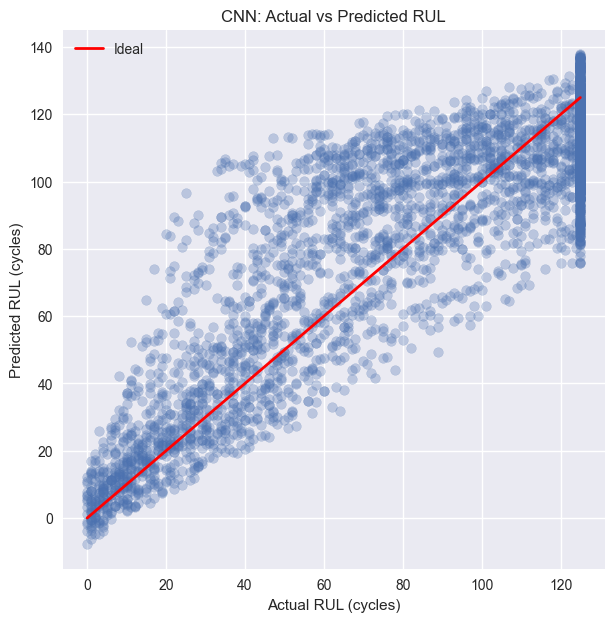

In [34]:
# ===============================
# CNN: Actual vs Predicted RUL
# ===============================

RUL_CAP = 125

y_true_rul = y_val * RUL_CAP
y_pred_rul = y_pred * RUL_CAP

plt.figure(figsize=(7,7))
plt.scatter(y_true_rul, y_pred_rul, alpha=0.3)
plt.plot([0, RUL_CAP], [0, RUL_CAP], 'r', linewidth=2, label="Ideal")
plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("CNN: Actual vs Predicted RUL")
plt.legend()
plt.grid(True)
plt.show()


Residual Error Distribution

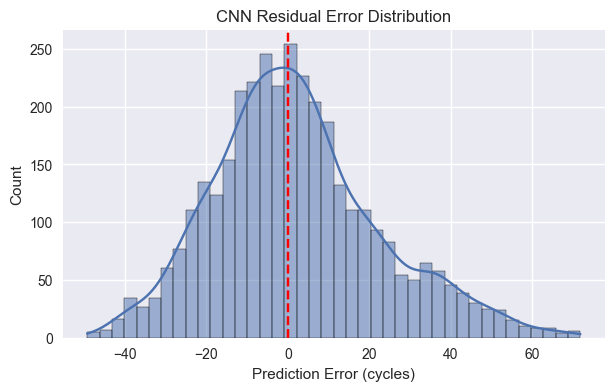

In [35]:
residuals = y_pred_rul - y_true_rul

plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction Error (cycles)")
plt.title("CNN Residual Error Distribution")
plt.show()

RUL Over Time (Single Engine)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


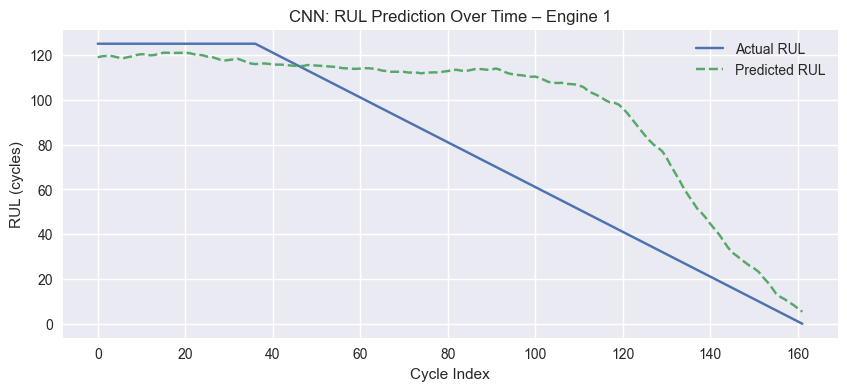

In [36]:

def plot_cnn_rul_over_time(engine_id, df, model, features, seq_len=30):
    engine_df = df[df.engine_id == engine_id].copy()

    if len(engine_df) <= seq_len:
        print("Not enough cycles")
        return

    X_engine, y_engine = create_sequences(engine_df, features, seq_len)

    y_pred_engine = model.predict(X_engine).flatten() * RUL_CAP
    y_true_engine = y_engine * RUL_CAP

    plt.figure(figsize=(10,4))
    plt.plot(y_true_engine, label="Actual RUL")
    plt.plot(y_pred_engine, '--', label="Predicted RUL")
    plt.xlabel("Cycle Index")
    plt.ylabel("RUL (cycles)")
    plt.title(f"CNN: RUL Prediction Over Time – Engine {engine_id}")
    plt.legend()
    plt.grid(True)
    plt.show()

    
# Example
plot_cnn_rul_over_time(1, train_df, model, features)

Sensor Degradation

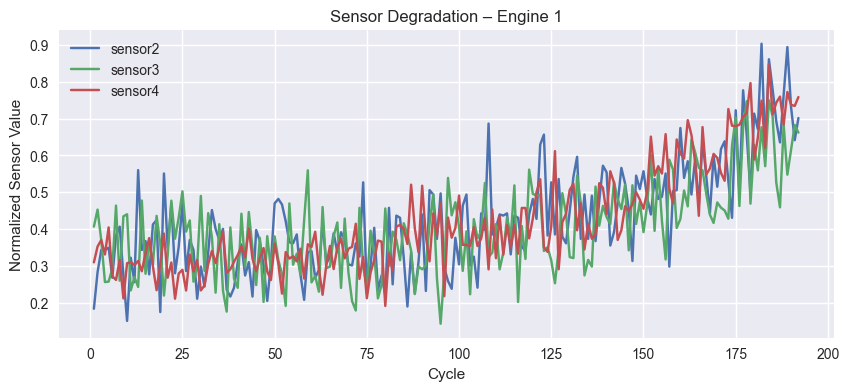

In [37]:
def plot_sensor_degradation(engine_id, df, features):
    engine_df = df[df.engine_id == engine_id]

    plt.figure(figsize=(10,4))
    for f in features[:3]:
        plt.plot(engine_df["cycle"], engine_df[f], label=f)

    plt.xlabel("Cycle")
    plt.ylabel("Normalized Sensor Value")
    plt.title(f"Sensor Degradation – Engine {engine_id}")
    plt.legend()
    plt.show()


plot_sensor_degradation(1, train_df, features)

CNN Metrics (For Comparison Table)

In [38]:
metrics_cnn = {
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
    "MAE": mean_absolute_error(y_val, y_pred),
    "R2": r2_score(y_val, y_pred)
}

metrics_cnn

{'RMSE': np.float64(0.1653045335853146),
 'MAE': 0.12707709076156484,
 'R2': 0.756696677621076}

Feature Importance via Correlation

In [39]:
# Compute absolute correlation with RUL
corr_values = train_df[features].corrwith(train_df["RUL"]).abs()

feature_importance_corr = (
    corr_values
    .sort_values(ascending=False)
    .reset_index()
)

feature_importance_corr.columns = ["Feature", "Importance"]

feature_importance_corr.head(10)

,Feature,Importance
0,sensor11,0.775230
1,sensor4,0.757157
2,sensor12,0.748870
3,sensor7,0.733021
4,sensor15,0.720858
5,sensor21,0.707334
6,sensor20,0.704626
7,sensor17,0.680829
8,sensor2,0.678458
9,sensor3,0.655030


Top Feature Importance Plot

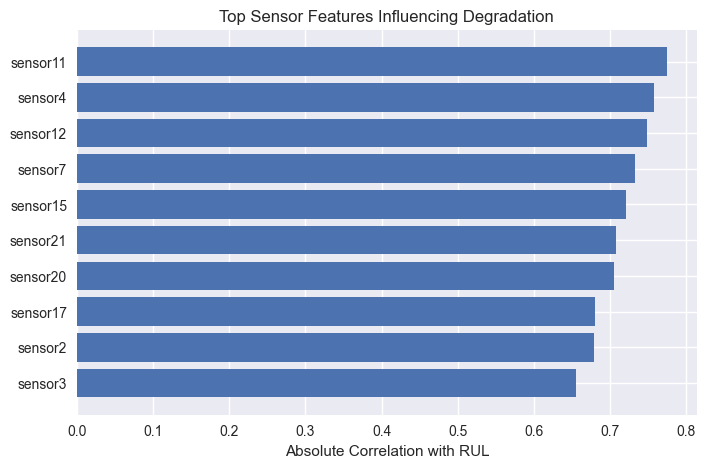

In [40]:
top_k = 10
top_features = feature_importance_corr.head(top_k)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Correlation with RUL")
plt.title("Top Sensor Features Influencing Degradation")
plt.show()

PERMUTATION IMPORTANCE

In [41]:

def permutation_importance_dl(
    model, X_val, y_val, features, n_repeats=3
):
    baseline_loss = model.evaluate(X_val, y_val, verbose=0)
    importances = {}

    for idx, feature in enumerate(features):
        losses = []

        for _ in range(n_repeats):
            X_permuted = X_val.copy()
            np.random.shuffle(X_permuted[:, :, idx])
            loss = model.evaluate(X_permuted, y_val, verbose=0)
            losses.append(loss)

        importances[feature] = np.mean(losses) - baseline_loss

    return importances


# Run permutation importance (LIMIT FEATURES IF NEEDED)
perm_importance = permutation_importance_dl(
    model,
    X_val,
    y_val,
    features[:10],   # limit for speed
    n_repeats=3
)

perm_df = (
    pd.DataFrame.from_dict(perm_importance, orient="index", columns=["Importance"])
    .sort_values("Importance", ascending=False)
)

perm_df

,Importance
sensor12,0.007560
sensor9,0.007052
sensor14,0.005185
sensor7,0.004830
sensor2,0.004346
sensor4,0.002385
sensor13,0.001852
sensor11,0.001093
sensor3,0.000306
sensor8,0.000236


Top Feature Importance Plot

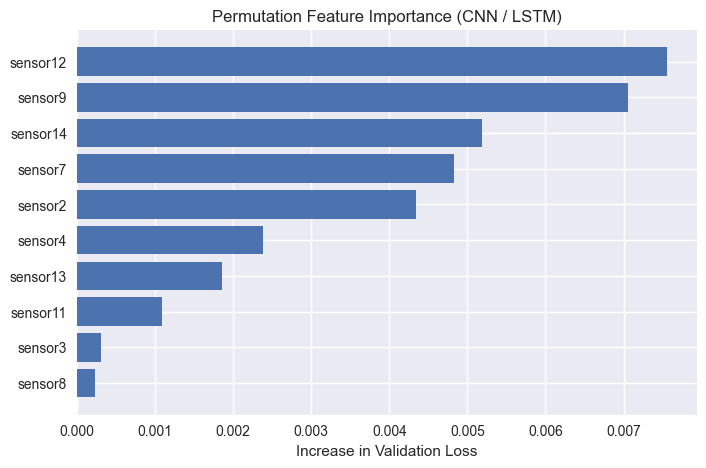

In [42]:
plt.figure(figsize=(8,5))
plt.barh(perm_df.index, perm_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Increase in Validation Loss")
plt.title("Permutation Feature Importance (CNN / LSTM)")
plt.show()